In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from pyreadstat import read_sav
from pyreadstat import metadata_container

np.random.seed(42)

In [2]:
df: pd.DataFrame; meta: metadata_container
df, meta = read_sav('data.sav')
df = df.drop('k4_new', axis=1)
print(df.shape)
df.head()

(2695, 22)


,Cреднеспис.числ.работн,k1,k2,k3,k4,k5,k6,k7,k8,k9,...,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
0,6095.0,0.942380,0.060563,0.678302,-0.161531,0.202055,0.165019,0.399033,0.799019,5.426569,...,1.082798,0.655937,4.454819,3.975687,0.892446,1007.536232,0.076738,0.055049,0.034904,5.0
1,255.0,1.980494,0.274382,0.916775,0.624425,0.089377,0.220648,0.000000,0.933519,14.041958,...,1.123828,0.705951,10.618881,12.295547,1.157895,357.294118,0.116068,0.059740,0.025647,5.0
2,114.0,0.374160,0.001494,0.085138,-1.504990,0.235739,0.508929,0.888889,0.779049,5.017007,...,1.185374,0.123415,0.794785,6.258929,7.875000,36.894737,-0.584879,0.010563,0.000000,5.0
3,365.0,7.859079,0.831978,2.449864,0.875862,0.059439,0.030030,0.011111,0.942010,16.244444,...,1.309449,2.804607,48.363889,26.142643,0.540541,33.676983,0.171731,0.496295,0.312415,5.0
4,168.0,1.779376,0.005596,0.883293,0.527853,0.135491,0.886686,0.489796,0.887341,10.558673,...,0.994832,0.473041,5.628827,3.125354,0.555241,19.103896,0.064809,0.025726,0.011839,5.0


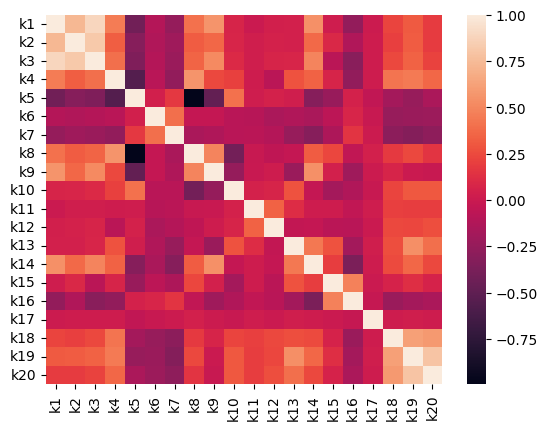

-0.996377824208808


In [3]:
sns.heatmap(df[df.columns[1:-1]].corr())
plt.show()
print(df[df.columns[1:-1]].corr()['k5']['k8'])

df = df.drop('k8', axis=1)
NUM_COLS = df.columns[1:-1]

Нахождение выбросов (Isolation forest)

In [4]:
from sklearn.ensemble import IsolationForest

df_train: pd.DataFrame; df_test: pd.DataFrame
print(f"Shape: {df.shape}")

clf = IsolationForest(
    n_estimators=500,           # Больше деревьев = стабильнее
    max_samples='auto',         # Можно попробовать 256, 512, 1024
    contamination='auto',       # или 0.05, или подобрать вручную
    max_features=0.8,           # Используем не все признаки сразу (боремся с шумом)
    bootstrap=False,
    random_state=42
)

clf.fit(df[NUM_COLS])
outliers_train: np.ndarray = clf.predict(df[NUM_COLS])

print(f"Number of outliers in df: {np.abs( outliers_train[outliers_train == -1].sum() )}")

Shape: (2695, 21)
Number of outliers in df: 136


Винсоризация:

In [5]:
outliers_mask = (outliers_train == -1)

percentiles = {}
for col in NUM_COLS:
    p_low: float = df[col][outliers_mask != 1].min()
    p_high = df[col][outliers_mask != 1].max()
    percentiles[col] = (p_low, p_high)

df_clean: pd.DataFrame = df.copy()
for col in NUM_COLS:
    low, high = percentiles[col]
    col_data = df_clean[col][outliers_mask]
    col_data[col_data < low] = low
    col_data[col_data > high] = high
    df_clean.loc[outliers_mask, col] = col_data

    
#df_clean = df[outliers_mask != 1]


Стандартизация:

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(df_clean)

df_array: np.ndarray = scaler.transform(df_clean)
df_stand: pd.DataFrame = pd.DataFrame(df_array,
                                             columns=df_clean.columns,
                                               index=df_clean.index)


Метод главных компонент:

In [7]:
from sklearn.decomposition import PCA

n_pca_components: int = 6
total_variance = np.sum(np.var(df_stand[NUM_COLS], axis=0, ddof=1))

pca = PCA(n_components=n_pca_components, random_state=42)
pca.fit(df_stand[NUM_COLS])
pca_eigen_values: np.ndarray = pca.explained_variance_

pca_res_df = pd.DataFrame(
    {"Eigen values": pca_eigen_values,
        "Explained variance ratio": pca.explained_variance_ratio_,
            "Cumsum of explained variance ratio": np.cumsum(pca.explained_variance_ratio_)},
    index=[i for i in range(n_pca_components)]
)
print(pca_res_df)

pca_array: np.ndarray = pca.transform(df_stand[NUM_COLS])
pca_columns: list[str] = ['pca_' + str(i + 1) for i in range(n_pca_components)]
df_pca: pd.DataFrame = pd.DataFrame(pca_array, columns=pca_columns, index=df_stand.index)
print("\nDataframe in principal components space:")
print(f"Shape: {df_pca.shape}")
print(df_pca.head())

   Eigen values  Explained variance ratio  Cumsum of explained variance ratio
0      5.131626                  0.269985                            0.269985
1      2.746323                  0.144490                            0.414475
2      1.724670                  0.090738                            0.505213
3      1.412437                  0.074311                            0.579525
4      1.156782                  0.060861                            0.640385
5      1.132669                  0.059592                            0.699977

Dataframe in principal components space:
Shape: (2695, 6)
      pca_1     pca_2     pca_3     pca_4     pca_5     pca_6
0 -1.062975  0.606016 -0.354002  0.288986 -0.852363  0.689220
1  0.892079  1.388750  0.435714  0.423050 -1.109801  0.258063
2 -5.405600  2.756024  0.156487 -0.176024  1.581223  1.062442
3  7.849036 -0.055441  1.447470 -1.429823 -0.342704 -0.477656
4 -1.023884  2.026061 -0.818490 -0.882516 -0.795567  3.037570


In [8]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loadings_df = pd.DataFrame(
    loadings,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df_stand[NUM_COLS].columns
)

print(loadings_df[loadings_df >= 0.5])

          PC1       PC2       PC3       PC4      PC5       PC6
k1   0.765868       NaN       NaN       NaN      NaN       NaN
k2   0.686758       NaN       NaN       NaN      NaN       NaN
k3   0.771632       NaN       NaN       NaN      NaN       NaN
k4   0.678220       NaN       NaN       NaN      NaN       NaN
k5        NaN       NaN       NaN       NaN      NaN       NaN
k6        NaN       NaN       NaN       NaN      NaN  0.629503
k7        NaN       NaN       NaN       NaN      NaN  0.522829
k9        NaN  0.672864       NaN       NaN      NaN       NaN
k10       NaN       NaN       NaN       NaN      NaN       NaN
k11       NaN       NaN       NaN  0.576104      NaN       NaN
k12       NaN       NaN       NaN  0.710528      NaN       NaN
k13       NaN       NaN       NaN       NaN      NaN       NaN
k14  0.691285       NaN       NaN       NaN      NaN       NaN
k15       NaN       NaN  0.862980       NaN      NaN       NaN
k16       NaN       NaN  0.591947       NaN  0.56405   

In [9]:
from factor_analyzer import Rotator

rotator = Rotator(method='quartimax')
rotated_loadings = rotator.fit_transform(loadings)

rotated_eig_vals = np.sum(rotated_loadings**2, axis=0)      # сумма квадратов по строкам (признакам)

components = [f"PC{i+1}_rot" for i in range(len(rotated_eig_vals))]
df_eigen = pd.DataFrame({
    "Component": components,
    "Eigenvalue": rotated_eig_vals,
    "Variance %": (rotated_eig_vals / total_variance) * 100,
    "Cumulative %": np.cumsum(rotated_eig_vals / total_variance) * 100
})
print(df_eigen)

  Component  Eigenvalue  Variance %  Cumulative %
0   PC1_rot    3.524505   18.543141     18.543141
1   PC2_rot    3.463325   18.221261     36.764402
2   PC3_rot    1.555570    8.184174     44.948576
3   PC4_rot    1.479613    7.784549     52.733126
4   PC5_rot    1.886587    9.925720     62.658846
5   PC6_rot    1.394908    7.338895     69.997741


In [10]:
df_rotated_loadings = pd.DataFrame(
    rotated_loadings,
    columns=[f'PC{i+1}_rot' for i in range(pca.n_components_)],
    index=df_stand[NUM_COLS].columns
)
print(df_rotated_loadings[df_rotated_loadings >= 0.4])

      PC1_rot  PC2_rot   PC3_rot   PC4_rot   PC5_rot   PC6_rot
k1   0.914956      NaN       NaN       NaN       NaN       NaN
k2   0.894563      NaN       NaN       NaN       NaN       NaN
k3   0.926204      NaN       NaN       NaN       NaN       NaN
k4        NaN      NaN       NaN       NaN       NaN       NaN
k5        NaN      NaN       NaN       NaN  0.780283       NaN
k6        NaN      NaN       NaN       NaN       NaN  0.745847
k7        NaN      NaN       NaN       NaN       NaN  0.683682
k9   0.574407      NaN       NaN       NaN       NaN       NaN
k10       NaN      NaN       NaN       NaN  0.744753       NaN
k11       NaN      NaN       NaN  0.624327       NaN       NaN
k12       NaN      NaN       NaN  0.789462       NaN       NaN
k13       NaN      NaN       NaN       NaN       NaN       NaN
k14  0.453463      NaN       NaN       NaN       NaN       NaN
k15       NaN      NaN  0.809260       NaN       NaN       NaN
k16       NaN      NaN  0.860641       NaN       NaN   

In [11]:
# New PCA space
T = np.linalg.pinv(loadings) @ rotated_loadings
rot_pca_array = pca_array @ T
rot_pca_df: pd.DataFrame = pd.DataFrame(
    rot_pca_array,
    columns=[f"PCA{i+1}_rot" for i in range(pca.n_components_)], 
    index=df_stand.index
)
rot_pca_df.head()

,PCA1_rot,PCA2_rot,PCA3_rot,PCA4_rot,PCA5_rot,PCA6_rot
0,-0.800414,0.857004,-0.647823,0.142358,-0.695486,0.780250
1,0.669841,0.076694,-0.397629,-0.133024,-1.932511,-0.162887
2,-1.839270,5.048817,1.693894,-0.500884,0.288363,2.902399
3,5.029059,-5.421747,-0.068484,-1.603075,-1.883551,-2.299244
4,-0.080189,0.966260,-1.046877,-0.850221,-1.469983,3.397354


Добавление интегрального показателя:

In [12]:
integral_score = np.zeros(rot_pca_df.shape[0])
for i, col in enumerate(rot_pca_df.columns):
    integral_score += rot_pca_df[col] * (rotated_eig_vals[i] / total_variance)

#integral_score_normalized = 50 + (integral_score - integral_score.mean()) / integral_score.std() * 10
df_final = df_stand.copy()
df_final['int_score'] = integral_score

Количество найденных кластеров: 4
Количество точек, отнесённых к шуму: 0
Метки кластеров (первые 10): [3 3 1 0 1 0 3 0 3 3]

Число наблюдений в каждом кластере:
0 240
1 513
2 556
3 1386
Index(['PCA1_rot', 'PCA2_rot', 'PCA3_rot', 'PCA4_rot', 'PCA5_rot', 'PCA6_rot'], dtype='str')


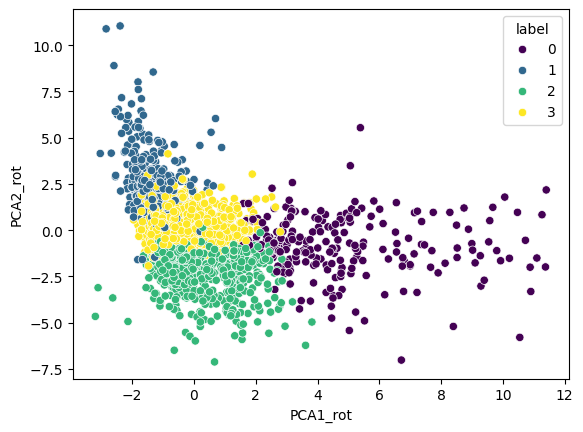

In [13]:
from sklearn.cluster import HDBSCAN
from sklearn.cluster import KMeans

#TODO: go from pca to pca_rotated

#clusterer = HDBSCAN(min_cluster_size=5, copy=False)
clusterer = KMeans(n_clusters=4, random_state=42)
clusterer.fit(rot_pca_df)

# Результаты
labels = clusterer.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # -1 метка для шума
n_noise = list(labels).count(-1)

print(f"Количество найденных кластеров: {n_clusters}")
print(f"Количество точек, отнесённых к шуму: {n_noise}")
print(f"Метки кластеров (первые 10): {labels[:10]}")
print("\nЧисло наблюдений в каждом кластере:")
#print(clusterer.probabilities_[:10])
for i in set(labels):
    print(i, np.sum(labels == i))

df_final['label'] = labels
print(rot_pca_df.columns)
#plt.scatter(df_pca['pca_1'], df_pca['pca_2'], с=labels, cmap='viridis')
sns.scatterplot(rot_pca_df, x='PCA1_rot', y='PCA2_rot', hue=df_final['label'], palette='viridis')
plt.show()

In [14]:
for i in range(4):
    print(df_final[df_final['label'] == i]['int_score'].mean())

0.5083067983410345
0.35671338606189346
-0.3496079499283796
-0.07980200468356463


In [77]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(df_final[NUM_COLS], df_final['label'], train_size=0.7)

In [16]:
rf = RandomForestClassifier(random_state=42)
scores = cross_val_score(rf, X_train, y_train, cv=5)

In [17]:
scores

array([0.87037037, 0.90450928, 0.90450928, 0.91511936, 0.89920424])

Hyperparameter tuning

In [19]:
hyperparams = {
    'n_estimators': [125, 150],
    'max_depth': [12, 16, 18, 20, 24, 30, None],
    'min_samples_leaf': [1, 2]
}

cross_val = GridSearchCV(rf, hyperparams, cv=5)
cross_val.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [12, 16, ...], 'min_samples_leaf': [1, 2], 'n_estimators': [125, 150]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sc

In [20]:
print(f"Optimal hyperparameter: {cross_val.best_params_}")
means = cross_val.cv_results_['mean_test_score']
stds = cross_val.cv_results_['std_test_score']

for mean, std, params in zip(means, stds, cross_val.cv_results_['params']):
    if mean > 0.9015:
        print(f"Mean {round(mean,3)} Standard Deviation {round(std * 2, 3)} Hyperparameters {params}")

Optimal hyperparameter: {'max_depth': 24, 'min_samples_leaf': 1, 'n_estimators': 150}


In [24]:
rfs = [
    RandomForestClassifier(n_estimators=150, max_depth=24, min_samples_leaf=1, class_weight=None)
]

for mdl in rfs:
    mdl.fit(X_train, y_train)

In [25]:
for mdl in rfs:
    y_pred = mdl.predict(X_test)
    accuracy = round(accuracy_score(y_test, y_pred), 3)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    print('Max Depth: {} || Estimators: {} || Accuracy: {} || Precision: {} || Recall: {}'.format(mdl.max_depth,
                                                                                                mdl.n_estimators,
                                                                                                accuracy,
                                                                                                precision,
                                                                                                recall))

Max Depth: 24 || Estimators: 150 || Accuracy: 0.902 || Precision: 0.902480264833206 || Recall: 0.9040256586190321


In [26]:
confusion_matrix(y_test, y_pred)

array([[ 72,   1,   0,   1],
       [  0, 142,   0,  26],
       [  4,   0, 133,  15],
       [  4,  11,  17, 383]])

In [86]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, solver='lbfgs', l1_ratio=0, max_iter=10000)
scores = cross_val_score(lr, X_train, y_train, cv=5)
scores

array([0.98412698, 0.95755968, 0.97877984, 0.97082228, 0.97082228])

In [87]:
# Сетка для подбора C
param_grid = {
    'C': np.logspace(-3, 3, 10) # от 0.001 до 100
}

# Поиск по сетке с кросс-валидацией
grid = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print(f"Лучшее значение C: {grid.best_params_['C']}")
print(f"Лучшая точность на кросс-валидации: {grid.best_score_:.4f}")

Лучшее значение C: 1000.0
Лучшая точность на кросс-валидации: 0.9867


In [88]:
best_lr = grid.best_estimator_
best_lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(1000.0)
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For

In [89]:
best_lr.coef_

array([[ 31.38085407,  31.73908738,  29.71657771,   5.64293494,
        -18.61487458, -10.11399906, -15.06971522,  35.2702553 ,
          7.49557414,   4.13796652,  -2.41099069,   9.30742139,
         20.22764525,  -6.02474996,  12.01214815,   0.69194087,
         -4.42807455,  20.65028962,   0.36750869],
       [-18.8303337 , -16.77461989, -24.30434027, -23.18928836,
         14.0172953 ,  22.25600942,  28.09354293, -15.98445019,
         -9.7078347 ,  -6.93347297,  -8.6312256 , -23.83575908,
        -31.51061459,   2.94411437,  16.89622365,  -4.99766689,
        -21.03420011, -32.94808858, -30.96841057],
       [ -1.77062166,  -3.94131683,   0.09616328,  16.47716865,
          0.928763  ,  -8.85602584, -11.09141625, -16.42125714,
          7.33971945,   5.23685834,  11.38874344,  16.07129159,
         10.32568163,   4.58697362, -13.37539653,   2.16616856,
         25.79947576,  17.8045256 ,  28.29767197],
       [-10.77989871, -11.02315066,  -5.50840072,   1.06918477,
          3.668

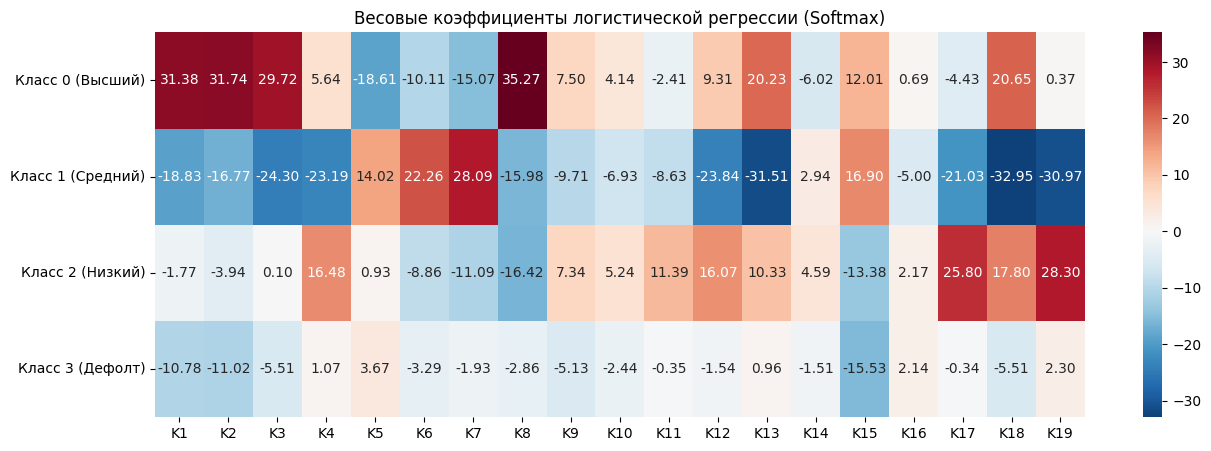

In [90]:
coef_matrix = best_lr.coef_
# coef_matrix - ваш массив 4x19
feature_names = [f'K{i+1}' for i in range(19)]
class_names = ['Класс 0 (Высший)', 'Класс 1 (Средний)', 'Класс 2 (Низкий)', 'Класс 3 (Дефолт)']

df_coef = pd.DataFrame(coef_matrix, index=class_names, columns=feature_names)

plt.figure(figsize=(15, 5))
sns.heatmap(df_coef, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Весовые коэффициенты логистической регрессии (Softmax)')
plt.show()

In [94]:
y_pred = best_lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
print(f"accuracy: {accuracy}, precision: {precision}, recall: {recall}, f1: {f1}")

accuracy: 0.9826946847960445, precision: 0.9784824960022566, recall: 0.9794057025077293, f1: 0.9787144728244641


In [92]:
confusion_matrix(y_test, y_pred)

array([[ 70,   0,   0,   1],
       [  0, 163,   0,   1],
       [  3,   0, 155,   6],
       [  1,   0,   2, 407]])